In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cartopy.crs as ccrs
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Rectangle
from IPython.display import HTML
from scipy.stats import linregress 

In [2]:
def select_by_latlon(ds, lat_target, lon_target):
    lat = ds['nav_lat'].values
    lon = ds['nav_lon'].values
    distance = np.sqrt((lat - lat_target)**2 + (lon - lon_target)**2)
    y_idx, x_idx = np.unravel_index(np.argmin(distance), distance.shape)
    print('x index =', x_idx)
    print('y index =', y_idx)
    return ds.isel(y=y_idx, x=x_idx)

In [3]:
from OceanDataStore import OceanDataCatalog

In [4]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")

In [5]:
catalog.available_collections

['noc-rapid-evolution', 'noc-npd-jra55', 'noc-npd-era5']

In [6]:
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [7]:
catalog.available_items

['noc-npd-era5/npd-eorca1-era5v1/gn/T1y',
 'noc-npd-era5/npd-eorca1-era5v1/gn/T1m',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1y_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',
 'noc-npd-era5/npd-eorca12-era5v1/gn/T5d_3d']

In [8]:
catalog.Items[4]

<Item id=noc-npd-era5/npd-eorca025-era5v1/gn/T5d_3d>

In [9]:
## Using 5-day means, from 1990 

ds1 = catalog.open_dataset(id=catalog.Items[4].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12',                        
                          bbox = (-85.0, 0.0, 0.0, 80.0))

min_region = ds1.sel(time_counter = ds1['time_counter'].dt.month.isin([2, 3, 4]))
max_region = ds1.sel(time_counter = ds1['time_counter'].dt.month.isin([8, 9, 10]))
min_temp = ((min_region['tos_con'].groupby('time_counter.year')).min(dim='time_counter')).compute()
max_temp = ((max_region['tos_con'].groupby('time_counter.year')).max(dim='time_counter')).compute()
Amplitudes_5day = max_temp - min_temp



C:\Users\TomAH\anaconda3\envs\env_ods\Lib\site-packages\flox\core.py:1502: RuntimeWarning: All-NaN slice encountered
  result = combine(array, axis=axis_, keepdims=True)


In [10]:
Amplitudes_5day

<xarray.DataArray 'tos_con' (year: 35, y: 482, x: 341)> Size: 23MB
array([[[        nan,  1.3211079 ,  1.2751617 , ..., -1.0330753 ,
         -1.0027676 , -1.0055141 ],
        [        nan,  1.3883095 ,  1.3767529 , ..., -1.3549328 ,
         -1.3191376 , -1.3312092 ],
        [        nan,  1.524189  ,  1.4584045 , ..., -1.6818848 ,
         -1.6469536 , -1.6263924 ],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,  2.486435  ,  2.4958477 , ..., -1.1363621 ,
         -1.160677  , -1.1802692 ],
        [        nan,  2.6282196 ,  2.6501923 , ..., -1.0816593 ,
         -1.1062393 , -1.1207829 ],
        [        nan,  2.609703  ,  2.6355362 , ..., -1.2344799 ,
         -1.2209702 , -1.2334881 ],
...
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,  2.0478306 ,  1.887188  , ..., -2.070757  ,
         -2.014742  , -1.99259   ],
        [        nan,  2.1330357 ,  1.9724255 , ..., -2.279459  ,
         -2.258974  , -2.248314  ],
        [        nan,  2.0166245 ,  1.8539486 , ..., -2.4375496 ,
         -2.3943214 , -2.4124928 ],
        ...,
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]]], shape=(35, 482, 341), dtype=float32)
Coordinates:
  * year     (year) int64 280B 1990 1991 1992 1993 1994 ... 2021 2022 2023 2024
    nav_lat  (y, x) float64 1MB 0.0 0.0 0.0 0.0 0.0 ... 79.51 79.41 79.3 79.2
    nav_lon  (y, x) float64 1MB -85.0 -84.75 -84.5 -84.25 ... 48.28 48.54 48.79
Dimensions without coordinates: y, x
Attributes:
    standard_name:       sea_surface_temperature
    long_name:           sea_surface_conservative_temperature
    units:               degC
    online_operation:    average
    interval_operation:  1800 s
    interval_write:      5 d
    cell_methods:        time: mean (interval: 1800 s)

In [11]:
## Calculating trends and p-values for amplitudes 

ny, nx = Amplitudes_5day.sizes['y'], Amplitudes_5day.sizes['x']
trend_data = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data = np.full((ny, nx), np.nan, dtype = np.float32) 

for y_idx in range (ny):
    for x_idx in range (nx):
        point = Amplitudes_5day.isel(y=y_idx, x=x_idx)
        try:
            slope, intercept, r_value, p_value, std_err = linregress(point['year'], point.values)
            trend_data[y_idx, x_idx] = slope 
            pval_data[y_idx, x_idx] = p_value
        except:
            trend_data[y_idx, x_idx] = np.nan
            pval_data[y_idx, x_idx] = np.nan

trend_da = xr.DataArray(data = trend_data, dims=["y", "x"], 
        coords={ "y": Amplitudes_5day['y'],
        "x": Amplitudes_5day['x'],
        "nav_lat": (("y", "x"), Amplitudes_5day['nav_lat'].values),
        "nav_lon": (("y", "x"), Amplitudes_5day['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST amplitude"})

pval_da = xr.DataArray(data = pval_data, dims=["y", "x"], 
        coords={ "y": Amplitudes_5day['y'],
        "x": Amplitudes_5day['x'],
        "nav_lat": (("y", "x"), Amplitudes_5day['nav_lat'].values),
        "nav_lon": (("y", "x"), Amplitudes_5day['nav_lon'].values)}, name="trend",
        attrs={"description": "P-value for linear trend over time of SST amplitude"})

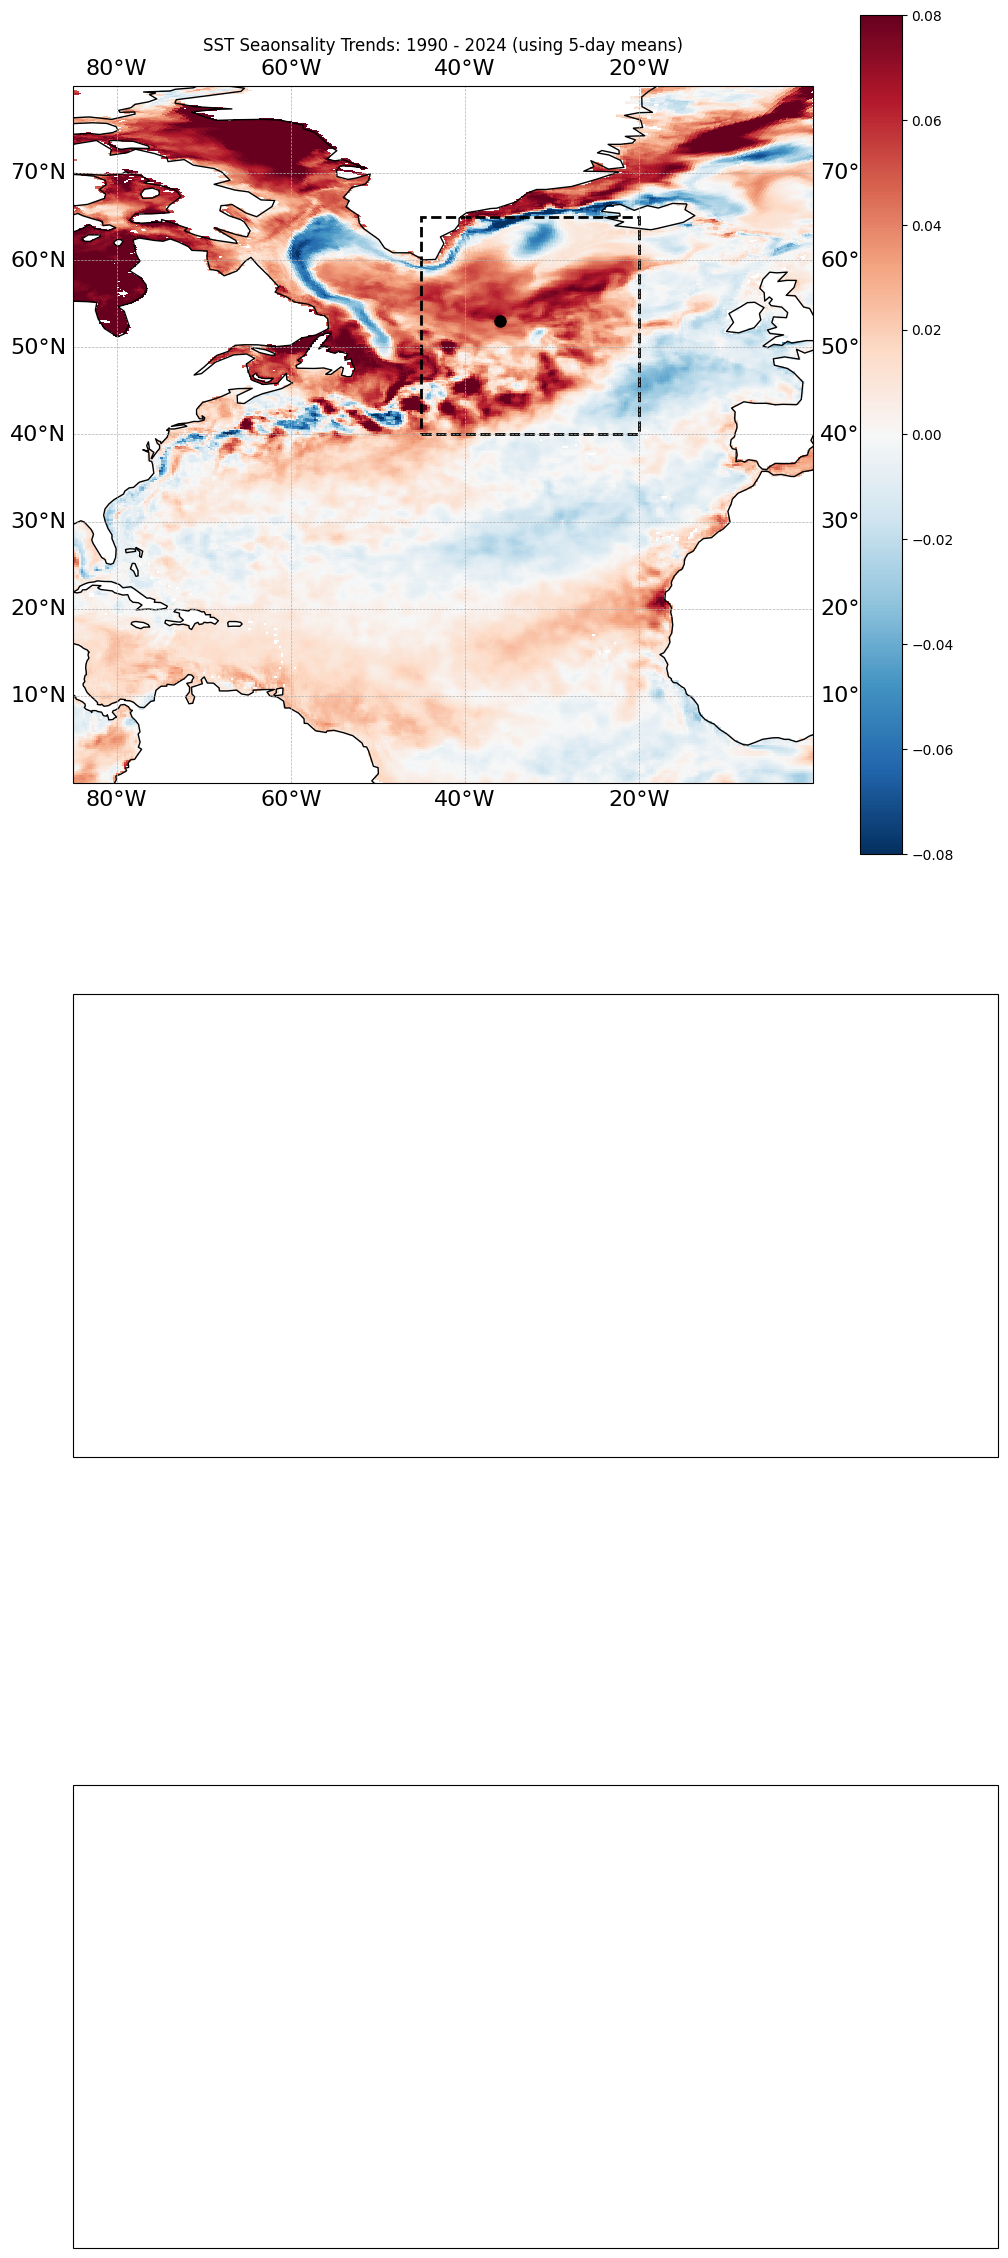

In [13]:
## Plotting trends, p-values for Amplitude and salinity 

fig, ax = plt.subplots(3, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 25))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax[2]

im = ax1.pcolormesh(trend_da['nav_lon'], trend_da['nav_lat'], trend_da, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax1.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax1.coastlines()
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
gl.xlabel_style = {'fontsize': 18}
gl.ylabel_style = {'fontsize': 16}
title = ax1.set_title('SST Seaonsality Trends: 1990 - 2024 (using 5-day means)')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax1.add_patch(box)
ax1.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

#im2 = ax2.pcolormesh(pval_da['nav_lon'], pval_da['nav_lat'], pval_da, cmap='viridis_r', transform=ccrs.PlateCarree(), vmin = 0.00, vmax = 0.10)  
#ax2.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
#cl2 = ax2.coastlines()
#gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
#title2 = ax2.set_title('P-value of fitted trend')
#box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
#ax2.add_patch(box)
#ax2.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

#mean_salinity = ds1['sos_abs'].mean(dim = 'time_counter')
#im3 = ax3.pcolormesh(ds1['nav_lon'], ds1['nav_lat'], mean_salinity, cmap = cmocean.cm.haline, transform = ccrs.PlateCarree(), vmin = 25, vmax = 38)
#ax3.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
#cl3 = ax3.coastlines()
#gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
#title3 = ax3.set_title('Global mean salinity')
#box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
#ax3.add_patch(box)
#ax3.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

plt.colorbar(im, ax=ax1)
#plt.colorbar(im2, ax=ax2)
#plt.colorbar(im3, ax=ax3)
plt.tight_layout()

#plt.savefig('Amplitude Trends.png')


In [10]:
## Calculating trends and p-values for maximums 

ny, nx = max_temp.sizes['y'], max_temp.sizes['x']
trend_data_max = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data_max = np.full((ny, nx), np.nan, dtype = np.float32) 

for y_idx in range (ny):
    for x_idx in range (nx):
        point = max_temp.isel(y=y_idx, x=x_idx)
        try:
            slope, intercept, r_value, p_value, std_err = linregress(point['year'], point.values)
            trend_data_max[y_idx, x_idx] = slope 
            pval_data_max[y_idx, x_idx] = p_value
        except:
            trend_data_max[y_idx, x_idx] = np.nan
            pval_data_max[y_idx, x_idx] = np.nan

trend_da_max = xr.DataArray(data = trend_data_max, dims=["y", "x"], 
        coords={ "y": max_temp['y'],
        "x": max_temp['x'],
        "nav_lat": (("y", "x"), max_temp['nav_lat'].values),
        "nav_lon": (("y", "x"), max_temp['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST maximum"})

pval_da_max = xr.DataArray(data = pval_data_max, dims=["y", "x"], 
        coords={ "y": max_temp['y'],
        "x": max_temp['x'],
        "nav_lat": (("y", "x"), max_temp['nav_lat'].values),
        "nav_lon": (("y", "x"), max_temp['nav_lon'].values)}, name="trend",
        attrs={"description": "P-value for linear trend over time of SST maximum"})

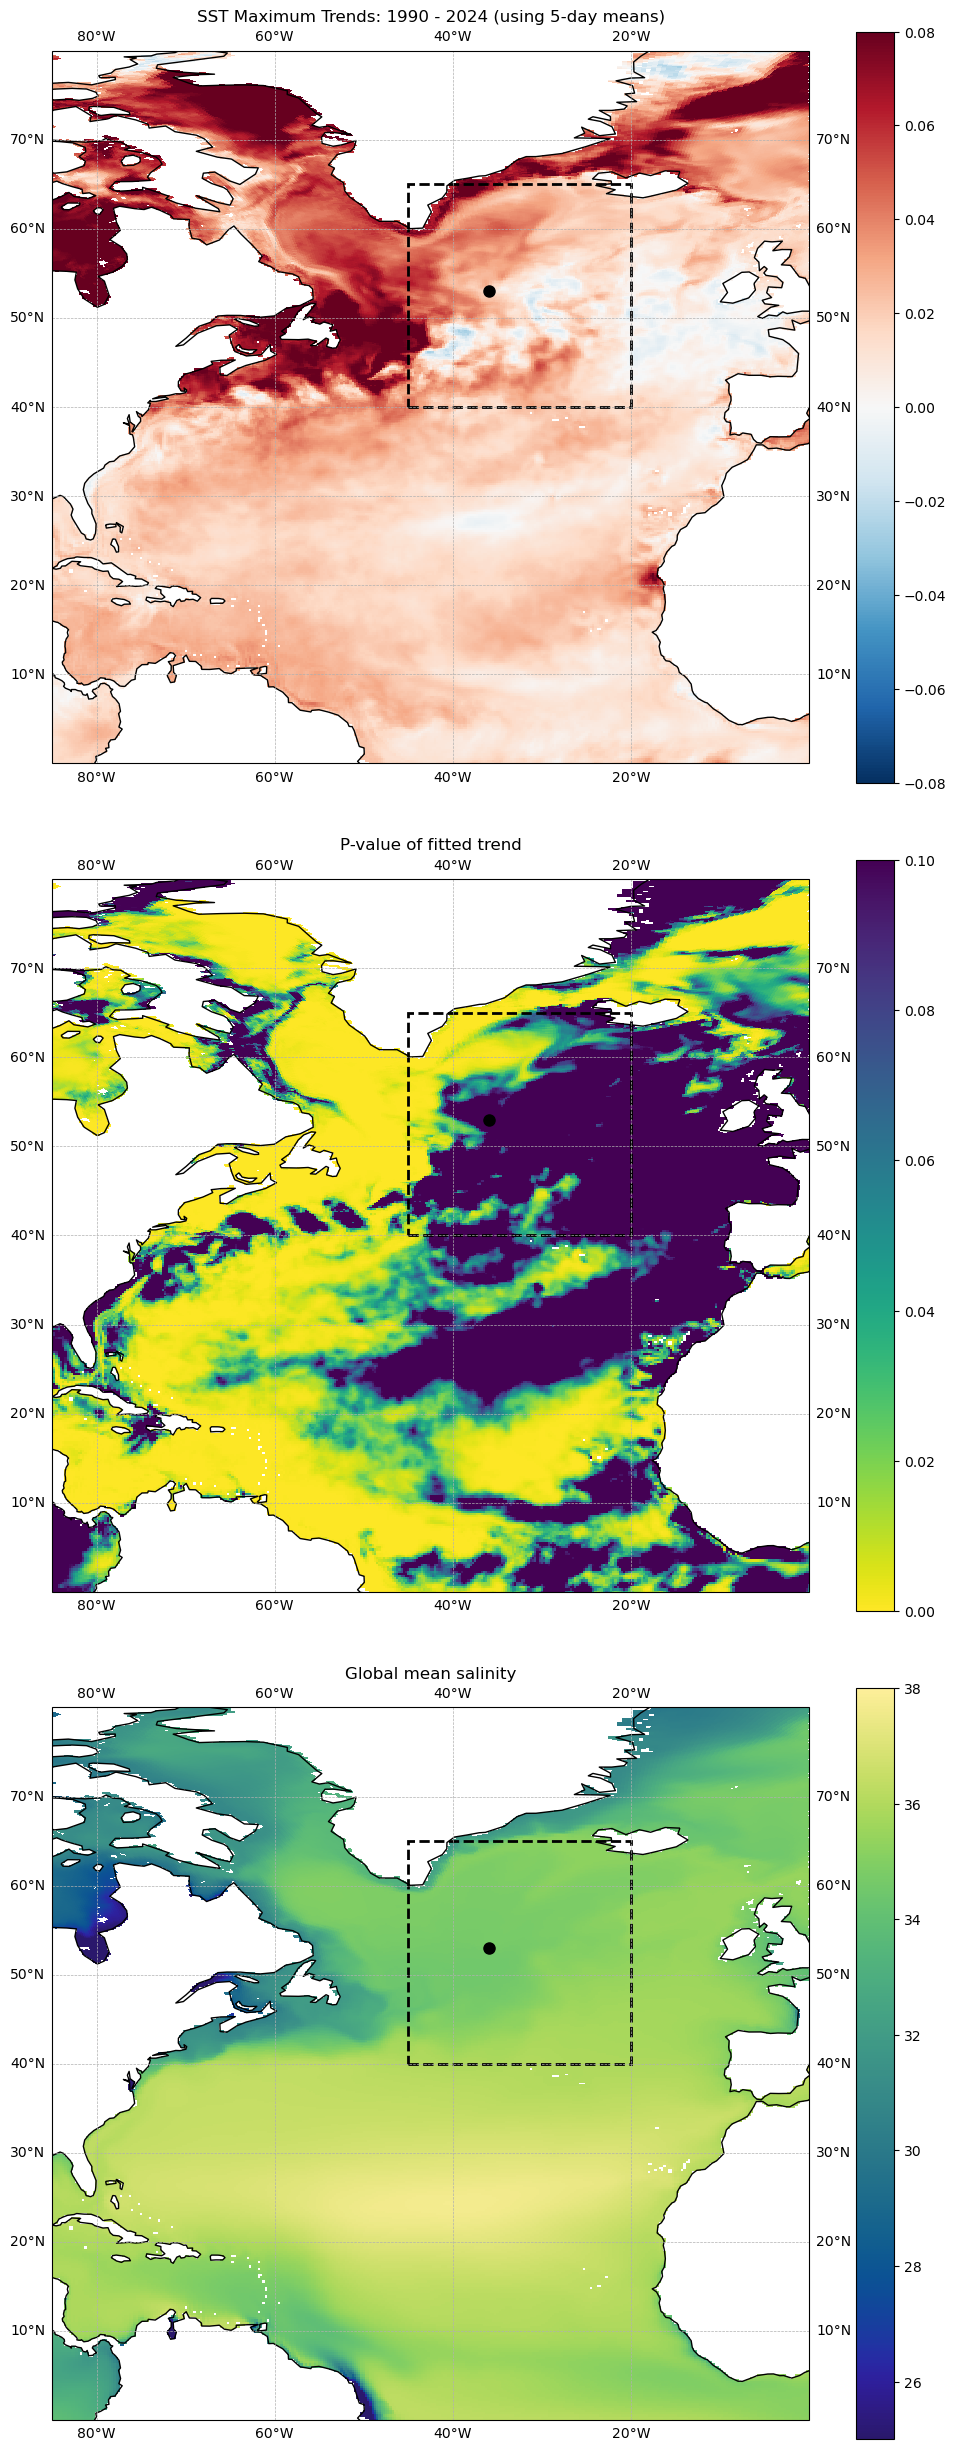

In [12]:
## Plotting trends, p-values for maximums and salinity 

fig, ax = plt.subplots(3, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 25))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax[2]

im = ax1.pcolormesh(trend_da_max['nav_lon'], trend_da_max['nav_lat'], trend_da_max, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax1.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax1.coastlines()
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title = ax1.set_title('SST Maximum Trends: 1990 - 2024 (using 5-day means)')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax1.add_patch(box)
ax1.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

im2 = ax2.pcolormesh(pval_da_max['nav_lon'], pval_da_max['nav_lat'], pval_da_max, cmap='viridis_r', transform=ccrs.PlateCarree(), vmin = 0.00, vmax = 0.10)  
ax2.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl2 = ax2.coastlines()
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title2 = ax2.set_title('P-value of fitted trend')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax2.add_patch(box)
ax2.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

mean_salinity = ds1['sos_abs'].mean(dim = 'time_counter')
im3 = ax3.pcolormesh(ds1['nav_lon'], ds1['nav_lat'], mean_salinity, cmap = cmocean.cm.haline, transform = ccrs.PlateCarree(), vmin = 25, vmax = 38)
ax3.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl3 = ax3.coastlines()
gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title3 = ax3.set_title('Global mean salinity')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax3.add_patch(box)
ax3.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

plt.colorbar(im, ax=ax1)
plt.colorbar(im2, ax=ax2)
plt.colorbar(im3, ax=ax3)
plt.tight_layout()

plt.savefig('Maximum Trends.png')

In [24]:
## Calculating trends and p-values for minimums 

ny, nx = min_temp.sizes['y'], min_temp.sizes['x']
trend_data_min = np.full((ny, nx), np.nan, dtype = np.float32)
pval_data_min = np.full((ny, nx), np.nan, dtype = np.float32) 

for y_idx in range (ny):
    for x_idx in range (nx):
        point = min_temp.isel(y=y_idx, x=x_idx)
        try:
            slope, intercept, r_value, p_value, std_err = linregress(point['year'], point.values)
            trend_data_min[y_idx, x_idx] = slope 
            pval_data_min[y_idx, x_idx] = p_value
        except:
            trend_data_min[y_idx, x_idx] = np.nan
            pval_data_min[y_idx, x_idx] = np.nan

trend_da_min = xr.DataArray(data = trend_data_min, dims=["y", "x"], 
        coords={ "y": min_temp['y'],
        "x": min_temp['x'],
        "nav_lat": (("y", "x"), min_temp['nav_lat'].values),
        "nav_lon": (("y", "x"), min_temp['nav_lon'].values)}, name="trend",
        attrs={"description": "Linear trend over time of SST minimum"})

pval_da_min = xr.DataArray(data = pval_data_min, dims=["y", "x"], 
        coords={ "y": min_temp['y'],
        "x": min_temp['x'],
        "nav_lat": (("y", "x"), min_temp['nav_lat'].values),
        "nav_lon": (("y", "x"), min_temp['nav_lon'].values)}, name="trend",
        attrs={"description": "P-value for linear trend over time of SST minimum"})

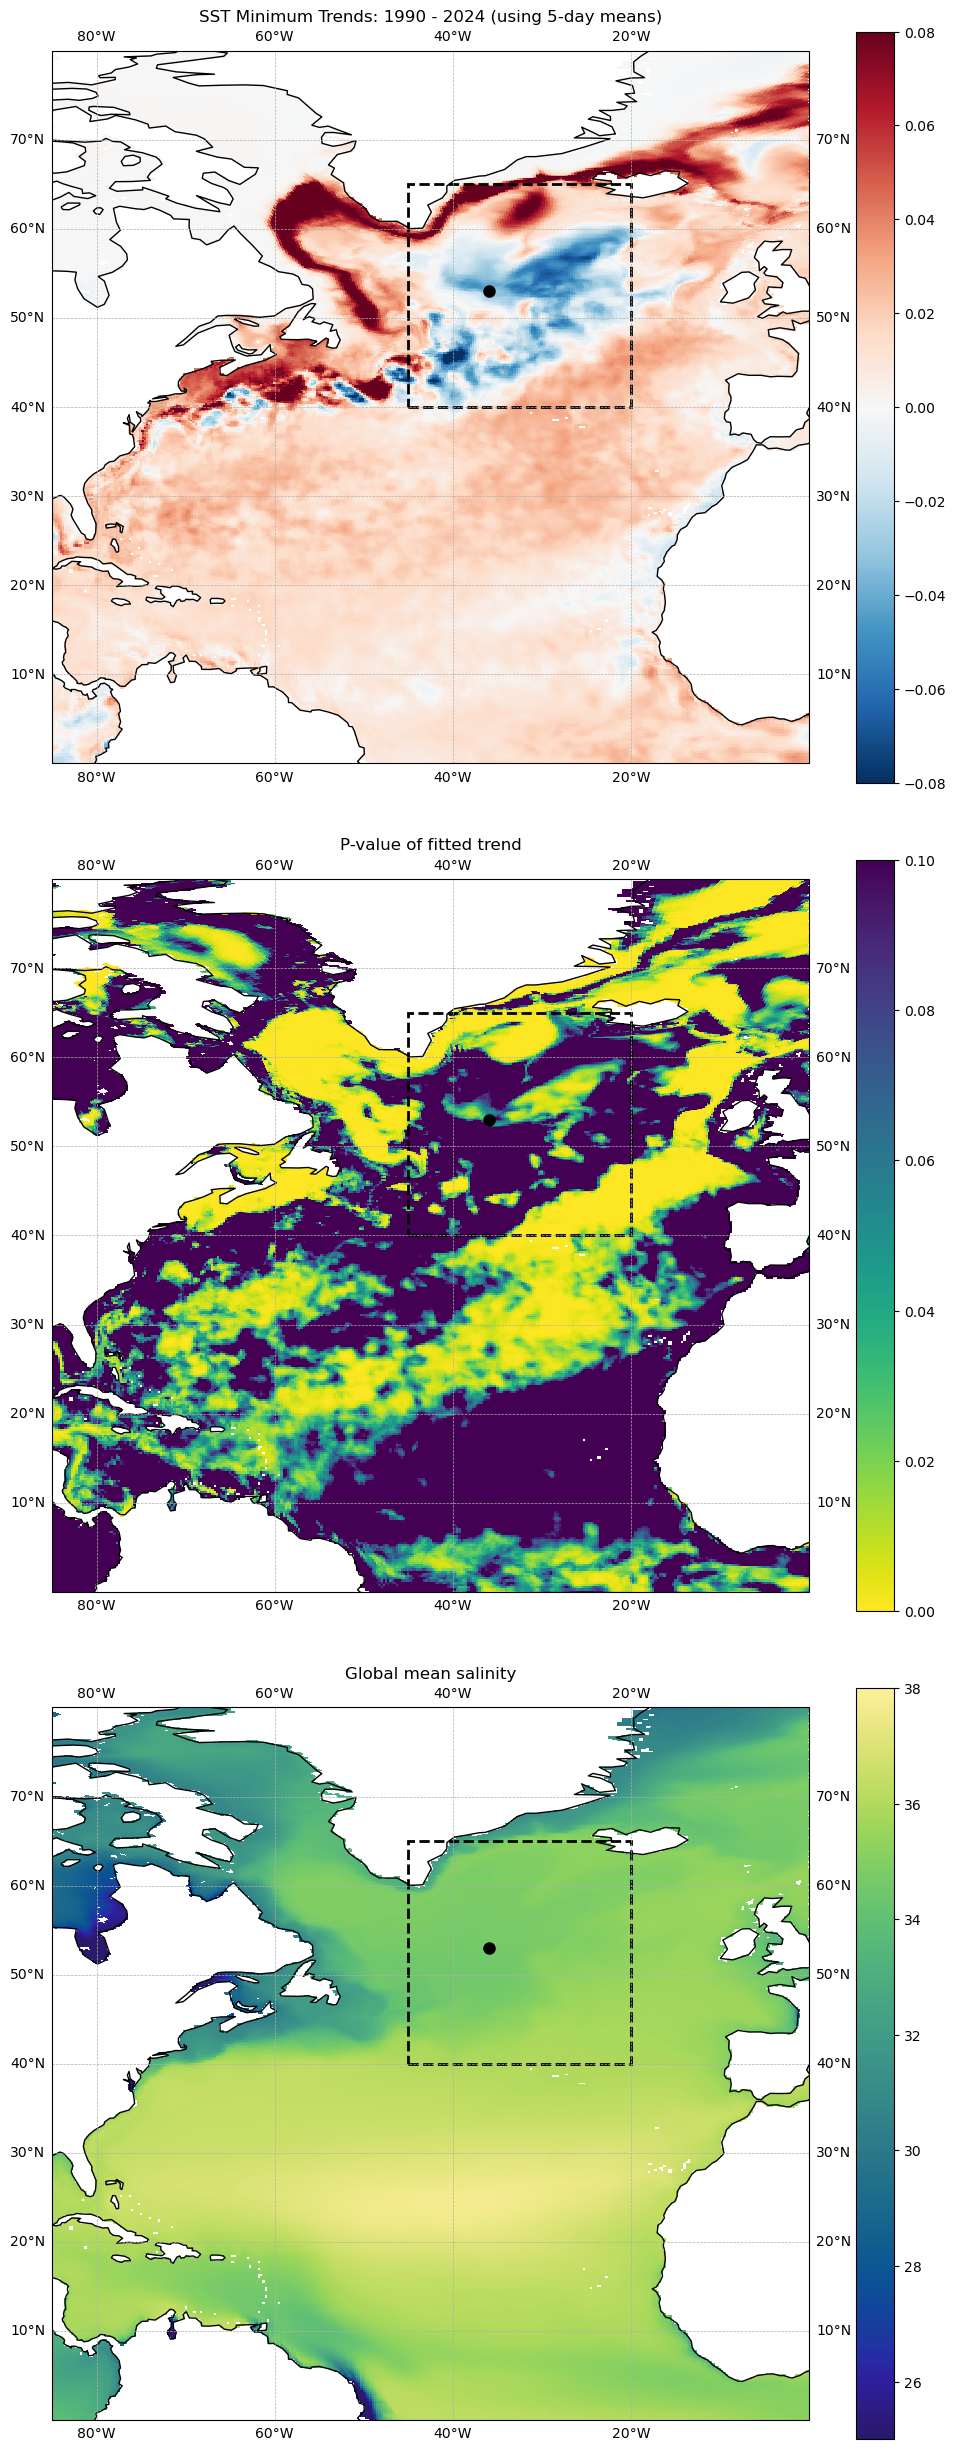

In [25]:
## Plotting trends, p-values for minimums and salinity 

fig, ax = plt.subplots(3, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 25))
ax1 = ax[0]
ax2 = ax[1]
ax3 = ax[2]

im = ax1.pcolormesh(trend_da_min['nav_lon'], trend_da_min['nav_lat'], trend_da_min, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin= -0.08, vmax=0.08)  
ax1.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl = ax1.coastlines()
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title = ax1.set_title('SST Minimum Trends: 1990 - 2024 (using 5-day means)')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax1.add_patch(box)
ax1.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

im2 = ax2.pcolormesh(pval_da_min['nav_lon'], pval_da_min['nav_lat'], pval_da_min, cmap='viridis_r', transform=ccrs.PlateCarree(), vmin = 0.00, vmax = 0.10)  
ax2.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl2 = ax2.coastlines()
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title2 = ax2.set_title('P-value of fitted trend')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax2.add_patch(box)
ax2.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

mean_salinity = ds1['sos_abs'].mean(dim = 'time_counter')
im3 = ax3.pcolormesh(ds1['nav_lon'], ds1['nav_lat'], mean_salinity, cmap = cmocean.cm.haline, transform = ccrs.PlateCarree(), vmin = 25, vmax = 38)
ax3.set_extent([-85.0, 0.0, 0.0, 80.0], crs=ccrs.PlateCarree())
cl3 = ax3.coastlines()
gl3 = ax3.gridlines(draw_labels=True, linewidth=0.5, linestyle='--')
title3 = ax3.set_title('Global mean salinity')
box = Rectangle((-45, 40), 25, 25, linewidth=2, edgecolor='black', facecolor='none', linestyle='--', transform=ccrs.PlateCarree())
ax3.add_patch(box)
ax3.plot(-36, 53, 'ko', markersize=8, transform=ccrs.PlateCarree())

plt.colorbar(im, ax=ax1)
plt.colorbar(im2, ax=ax2)
plt.colorbar(im3, ax=ax3)
plt.tight_layout()

plt.savefig('Minimum Trends.png')